# **Mini-Project 1**

### Load + Understanding

In [26]:
import pandas as pd
import numpy as np

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.shape
df.head()
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


### Data Quality & Cleaning

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [29]:
df["customerID"].duplicated().sum()

np.int64(0)

In [30]:
df["TotalCharges"].value_counts().head(10)

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
19.65,8
19.55,7
45.3,7
20.15,6


In [31]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [32]:
df[df["TotalCharges"].str.strip() == ""][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [33]:
# from "" to 0
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [34]:
df["TotalCharges"].dtype

dtype('float64')

In [35]:
df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [36]:
df["tenure"].min(), df["tenure"].max()

(0, 72)

In [37]:
df["MonthlyCharges"].min(), df["MonthlyCharges"].max()

(18.25, 118.75)

### EDA

In [38]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [39]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [40]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


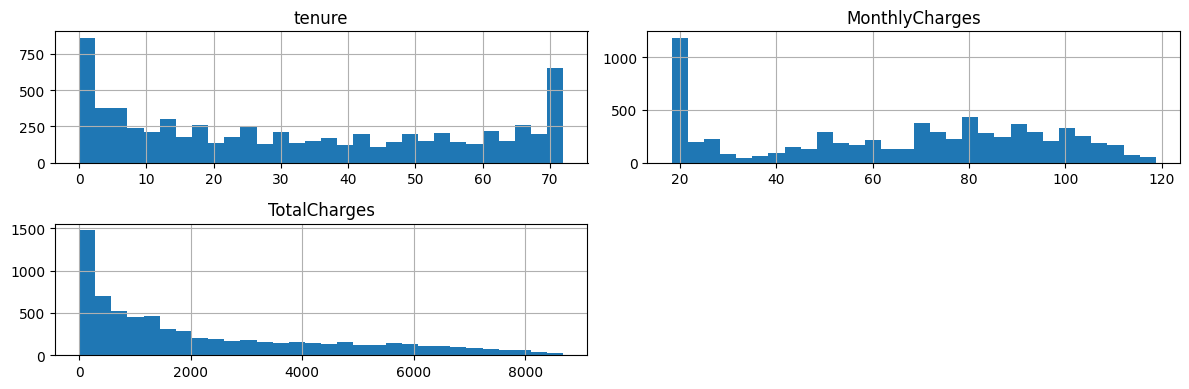

In [41]:
import matplotlib.pyplot as plt

df[["tenure", "MonthlyCharges", "TotalCharges"]].hist(
    figsize=(12, 4),
    bins=30
)

plt.tight_layout()
plt.show()

In [42]:
# cate distribution
categorical_cols = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Contract
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

PaymentMethod
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

SeniorCitizen
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64


In [43]:
churn_by_contract = (
    df.groupby("Contract")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values())

churn_by_contract

,Churn
Contract,
Two year,2.831858
One year,11.269518
Month-to-month,42.709677


In [44]:
churn_by_internet = (
    df.groupby("InternetService")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

churn_by_internet

,Churn
InternetService,
Fiber optic,41.892765
DSL,18.959108
No,7.404980


In [45]:
churn_by_payment = (
    df.groupby("PaymentMethod")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

churn_by_payment

,Churn
PaymentMethod,
Electronic check,45.285412
Mailed check,19.106700
Bank transfer (automatic),16.709845
Credit card (automatic),15.243101


In [46]:
churn_by_senior = (
    df.groupby("SeniorCitizen")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False))

churn_by_senior

,Churn
SeniorCitizen,
1,41.681261
0,23.606168


In [47]:
df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr(numeric_only=True)

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


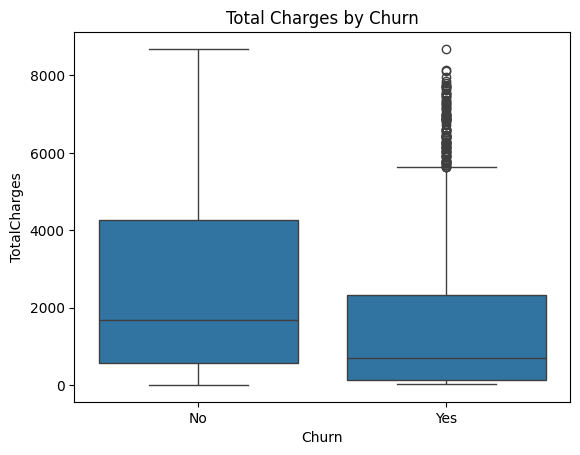

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("Total Charges by Churn")
plt.show()

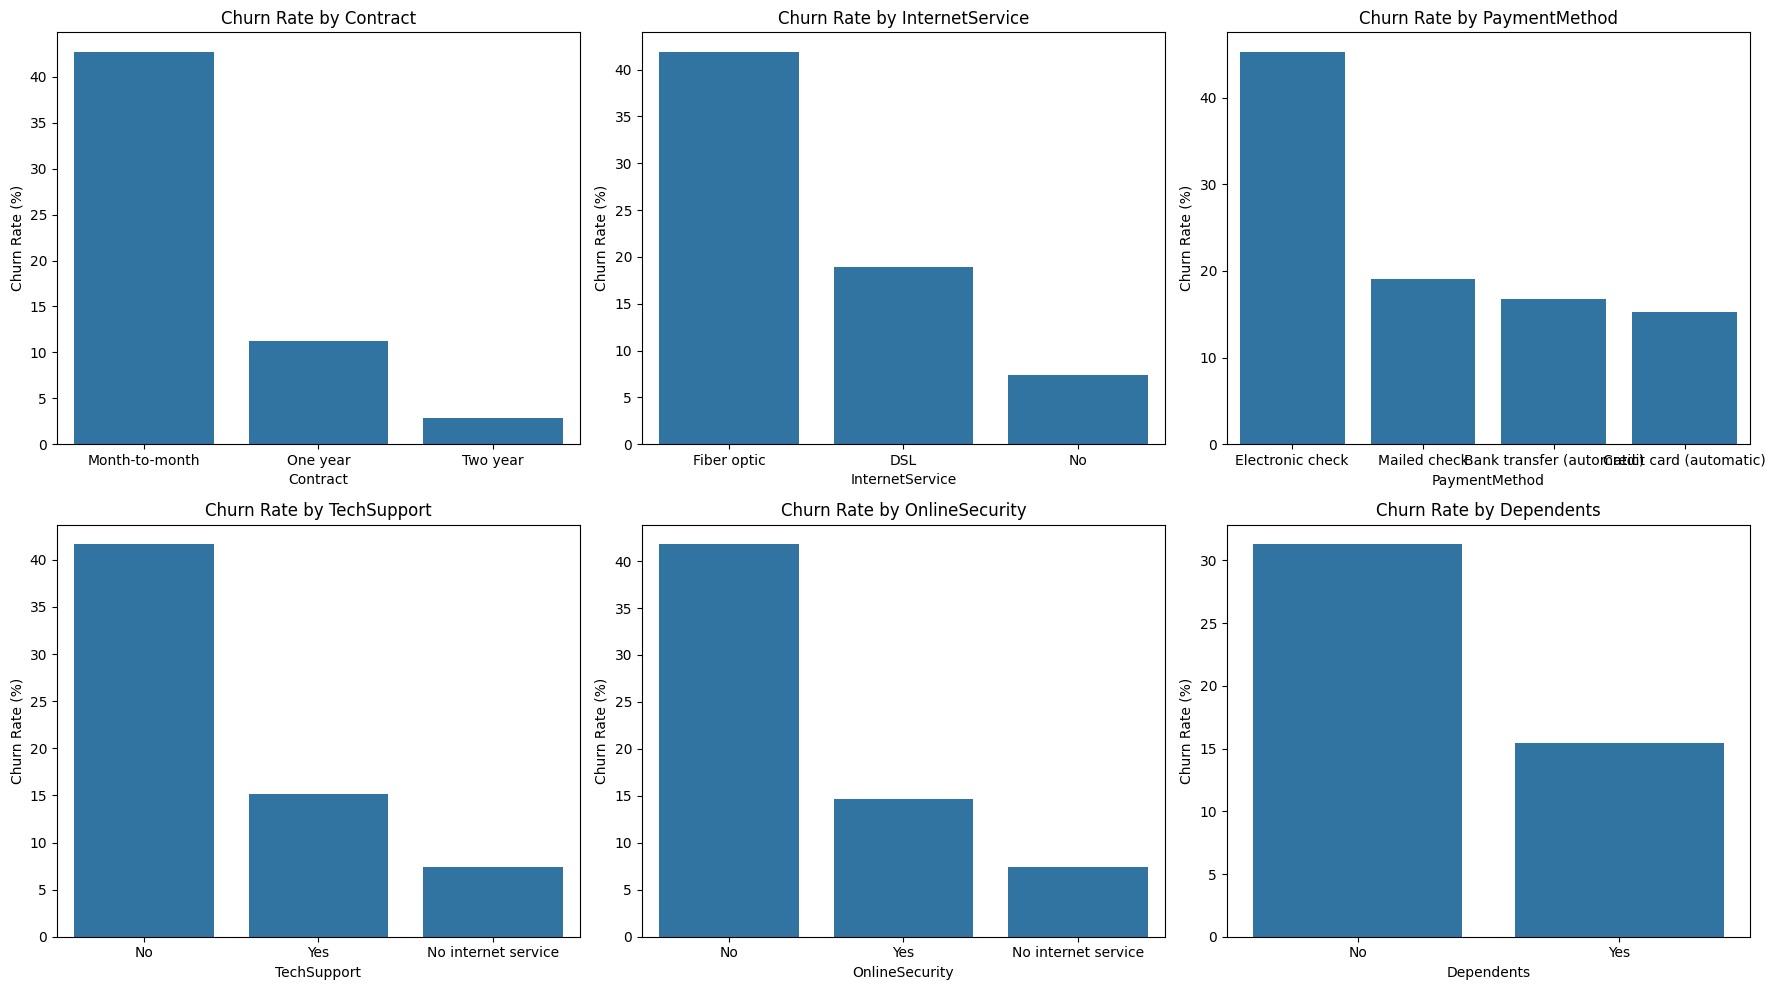

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_cols = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity",
    "Dependents"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flat, categorical_cols):

    churn_rate = (
        df.groupby(col)["Churn"]
          .apply(lambda x: (x == "Yes").mean() * 100)
          .sort_values(ascending=False)
    )

    sns.barplot(
        x=churn_rate.index,
        y=churn_rate.values,
        ax=ax
    )

    ax.set_title(f"Churn Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

### Feature Engineering

In [50]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [51]:
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [52]:
# 1. Customer Type
customer_type = []

for tenure in df["tenure"]:
    if tenure <= 12:
        customer_type.append("New Customer")
    else:
        customer_type.append("Old Customer")

df["CustomerType"] = customer_type


In [53]:
# 2. Average Monthly Spend
df["AvgMonthlySpend"] = df["TotalCharges"] / df["tenure"].replace(0, 1)


In [54]:
# 3. Total Services
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

total_services = []

for i in range(len(df)):
    count = 0

    for col in service_cols:
        if df.loc[i, col] == "Yes":
            count += 1

    total_services.append(count)

df["TotalServices"] = total_services


In [55]:

# Check results
df[[
    "tenure",
    "CustomerType",
    "AvgMonthlySpend",
    "TotalServices"
]].head()

,tenure,CustomerType,AvgMonthlySpend,TotalServices
0,1,New Customer,29.850000,1
1,34,Old Customer,55.573529,2
2,2,New Customer,54.075000,2
3,45,Old Customer,40.905556,3
4,2,New Customer,75.825000,0


In [56]:
spending_segment = []

for charge in df["MonthlyCharges"]:
    if charge < 50:
        spending_segment.append("Low Spender")
    elif charge < 80:
        spending_segment.append("Medium Spender")
    else:
        spending_segment.append("High Spender")

df["SpendingSegment"] = spending_segment

In [57]:
service_segment = []

for services in df["TotalServices"]:
    if services <= 1:
        service_segment.append("Basic Customer")
    elif services <= 3:
        service_segment.append("Multi-Service Customer")
    else:
        service_segment.append("Highly Engaged Customer")

df["ServiceSegment"] = service_segment

### Save data

In [58]:
# Save the final dataset
df.to_csv("Mini V2 py.csv", index=False)
